In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  #

dictionary = {
    "names" : ["Davide", "Valerio", "Andrea", "Giulia", "Luigi", "Miriam", "Jesus", "Davide", "Valerio"],
    "ages" : [22, 21, 21 , 21 , 18, 14, 33, None,21],
    "hobby" : ["A.I", "gym", "studing", "being cool", None, "talking", "being merciful", "studing", "gym"]
}

df = pd.DataFrame(dictionary)
print(df)

     names  ages           hobby
0   Davide  22.0             A.I
1  Valerio  21.0             gym
2   Andrea  21.0         studing
3   Giulia  21.0      being cool
4    Luigi  18.0            None
5   Miriam  14.0         talking
6    Jesus  33.0  being merciful
7   Davide   NaN         studing
8  Valerio  21.0             gym


# Prepring our datas for The A.I Model

**Data preparation** is the process of cleaning, transforming, and organizing raw data to make it suitable for analysis, visualization, and machine learning models, improving its quality and reliability.

Real-world datasets are never perfect: they may contain errors, missing values, duplicates, or redundant variables.  
A machine learning model can only perform well if the data is perfectly clean and consistent.

**Purpose of preparation:**
- Detect and address problems in the data  
- Transform variables into formats readable by algorithms  
- Reduce noise while preserving useful information

## **Handling missing entryes in our data 
- Missing Completely At Random (MCAR): Datas are missing for no reason in our dataset
- Missing At Random (MAR): Datas are missing for a reason that could be understood by looking at other Datas in the dataset
- Missing Not at Random (MNAR): Datas are missing because there was a reason for that data to be missing 

#### Handling missing datas example:

In [24]:
print("Missing values for column :\n")
print(df.isna().sum())
print("\nGeneral healt info : \n")
df.info()


Missing values for column :

names    0
ages     1
hobby    1
dtype: int64

General healt info : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   names   9 non-null      object 
 1   ages    8 non-null      float64
 2   hobby   8 non-null      object 
dtypes: float64(1), object(2)
memory usage: 348.0+ bytes


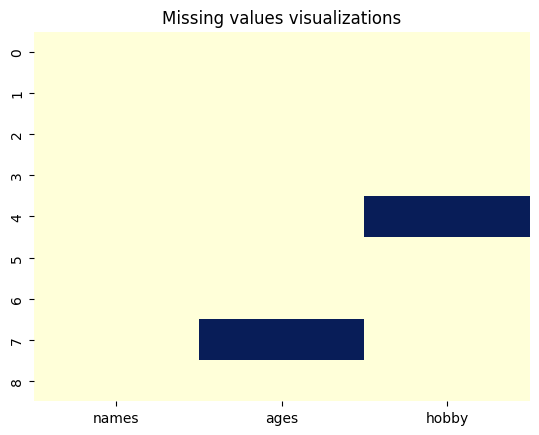

In [25]:
sns.heatmap(df.isna(), cbar=False, cmap="YlGnBu") # heatmap has as imput a dataframe with true and falses value of course white is true black is false
plt.title("Missing values visualizations")
plt.show()

# Handling missing datas 

For fixing datasets with missing datas we have various approach :
- Delete them  if there are not many 
- Fixing them with the most common category if for example name or the mean or median value if a number

### Sobstitution Example for a numeric value:

In [26]:
df["ages"] = df["ages"].fillna(df["ages"].mean())
print(df)

     names    ages           hobby
0   Davide  22.000             A.I
1  Valerio  21.000             gym
2   Andrea  21.000         studing
3   Giulia  21.000      being cool
4    Luigi  18.000            None
5   Miriam  14.000         talking
6    Jesus  33.000  being merciful
7   Davide  21.375         studing
8  Valerio  21.000             gym


#### Sobstitution Example for a text value:

In [27]:
df["hobby"] = df["hobby"].fillna(df["hobby"].mode()[0])
print(df)

     names    ages           hobby
0   Davide  22.000             A.I
1  Valerio  21.000             gym
2   Andrea  21.000         studing
3   Giulia  21.000      being cool
4    Luigi  18.000             gym
5   Miriam  14.000         talking
6    Jesus  33.000  being merciful
7   Davide  21.375         studing
8  Valerio  21.000             gym


# Handling Duplicate datas

We have:
- **Exact duplicates**: identical rows repeated.
- **Partial duplicates**: same values in certain key columns.

**Problems caused by duplicates:**
- Distortion in statistics (counts, averages, frequencies)
- Overestimation of certain cases


In [28]:
# Printing how much each column values are null
for col in df.columns:
    print(f"Duplicate values in {col} : {df[col].duplicated().sum()}") # note that first occurence is not counted
    
print("\n\n", df)

print("\n About to remove :\n", df[df.duplicated(subset=["names"], keep="first")])

# Removing the row if a specific column entry is a duplicate
df = df.drop_duplicates(subset="names", keep="first") # subset tells us in wich column do the search 
print("\n\n", df) # Valerio has been removed because all the row was equal



Duplicate values in names : 2
Duplicate values in ages : 3
Duplicate values in hobby : 3


      names    ages           hobby
0   Davide  22.000             A.I
1  Valerio  21.000             gym
2   Andrea  21.000         studing
3   Giulia  21.000      being cool
4    Luigi  18.000             gym
5   Miriam  14.000         talking
6    Jesus  33.000  being merciful
7   Davide  21.375         studing
8  Valerio  21.000             gym

 About to remove :
      names    ages    hobby
7   Davide  21.375  studing
8  Valerio  21.000      gym


      names  ages           hobby
0   Davide  22.0             A.I
1  Valerio  21.0             gym
2   Andrea  21.0         studing
3   Giulia  21.0      being cool
4    Luigi  18.0             gym
5   Miriam  14.0         talking
6    Jesus  33.0  being merciful
